# Model Comparison: ROC Curves & Confusion Matrices

Side-by-side evaluation of **Baseline CNN**, **Tuned CNN**, and **EfficientNet-B0** on the held-out test split.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from PIL import Image
from pathlib import Path
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
CLASS_NAMES = ['heavy', 'incident', 'light', 'moderate']
NUM_CLASSES  = len(CLASS_NAMES)

BASELINE_WEIGHTS     = Path('models/baseline_cnn_weights.pth')
TUNED_WEIGHTS        = Path('models/tuned_cnn_weights -MAC.pth')
EFFICIENTNET_WEIGHTS = Path('efficientnet_b0_weights.pth')
TEST_DIR             = Path('merged_dataset/test')

print(f'Device : {DEVICE}')
print(f'Test dir exists: {TEST_DIR.exists()}')

Device : mps
Test dir exists: True


In [3]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.act1    = nn.ReLU()
        self.pool1   = nn.MaxPool2d(2, 2)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.act2    = nn.ReLU()
        self.pool2   = nn.MaxPool2d(2, 2)
        self.conv3   = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.act3    = nn.ReLU()
        self.pool3   = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(128 * 16 * 16, 512)
        self.act4    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = self.pool3(self.act3(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = self.dropout(self.act4(self.fc1(x)))
        return self.fc2(x)


class TunableCNN(nn.Module):
    """Architecture matches tuned_cnn_weights -MAC.pth (no BatchNorm, single hidden FC)."""
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 0
            nn.ReLU(inplace=True),                         # 1
            nn.MaxPool2d(2, 2),                            # 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 3
            nn.ReLU(inplace=True),                         # 4
            nn.MaxPool2d(2, 2),                            # 5
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 6
            nn.ReLU(inplace=True),                         # 7
            nn.MaxPool2d(2, 2),                            # 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # 0
            nn.Linear(128 * 16 * 16, 512),       # 1
            nn.ReLU(inplace=True),               # 2
            nn.Dropout(dropout_rate),            # 3
            nn.Linear(512, num_classes),         # 4
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ApplyCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np     = np.array(img)
        img_lab    = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b    = cv2.split(img_lab)
        l_eq       = self.clahe.apply(l)
        img_lab_eq = cv2.merge((l_eq, a, b))
        return Image.fromarray(cv2.cvtColor(img_lab_eq, cv2.COLOR_LAB2RGB))

In [4]:
cnn_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

efficientnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [5]:
def load_baseline():
    m = BaselineCNN(num_classes=NUM_CLASSES)
    m.load_state_dict(torch.load(BASELINE_WEIGHTS, map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_tuned():
    m = TunableCNN(num_classes=NUM_CLASSES, dropout_rate=0.3)
    m.load_state_dict(torch.load(TUNED_WEIGHTS, map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_efficientnet():
    m = models.efficientnet_b0(weights=None)
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(1280, NUM_CLASSES),
    )
    m.load_state_dict(torch.load(EFFICIENTNET_WEIGHTS, map_location=DEVICE))
    return m.to(DEVICE).eval()

baseline_model = load_baseline()
tuned_model    = load_tuned()
effnet_model   = load_efficientnet()
print('All three models loaded.')

All three models loaded.


In [6]:
def run_inference(model, transform):
    dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
    loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
    y_true, probs_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            probs_list.append(probs)
            y_true.extend(labels.numpy())
    return np.array(y_true), np.vstack(probs_list)

print('Running inference on test set...')
y_base,   p_base   = run_inference(baseline_model, cnn_transform)
y_tuned,  p_tuned  = run_inference(tuned_model,    cnn_transform)
y_effnet, p_effnet = run_inference(effnet_model,   efficientnet_transform)
print('Done.')

MODELS = [
    ('Baseline CNN',    y_base,   p_base),
    ('Tuned CNN',       y_tuned,  p_tuned),
    ('EfficientNet-B0', y_effnet, p_effnet),
]

Running inference on test set...
Done.


## AUC-ROC Curves (One-vs-Rest)

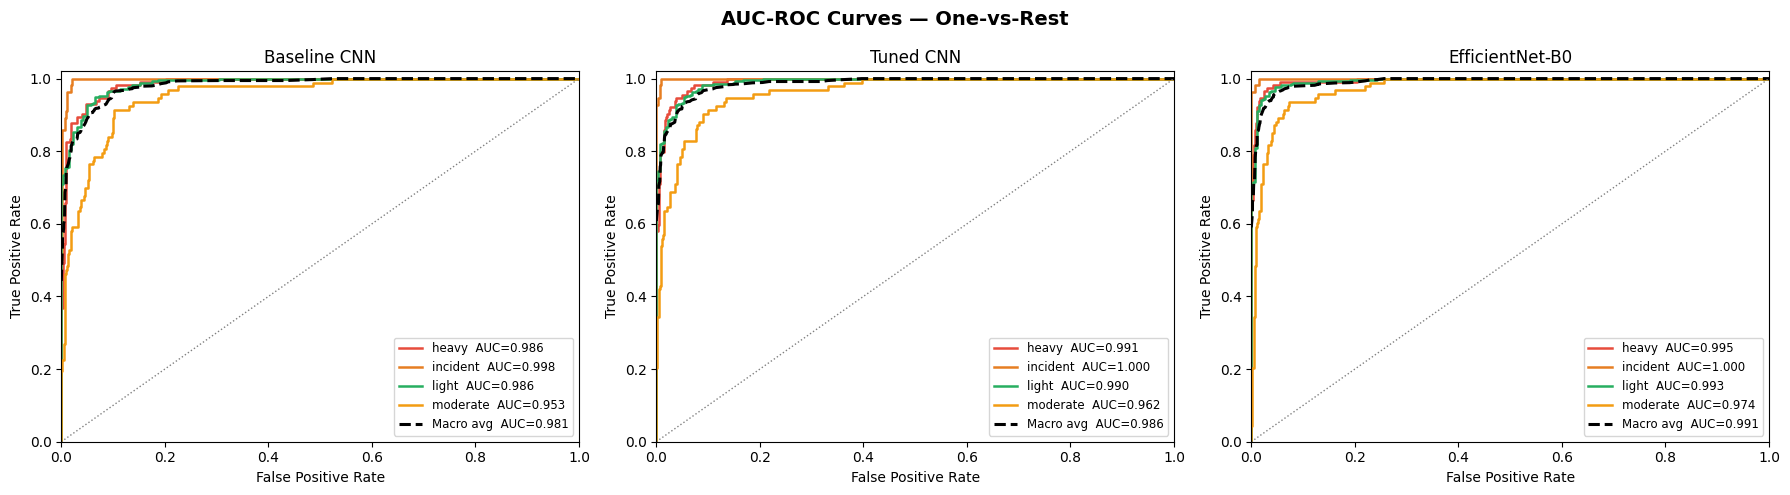

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AUC-ROC Curves — One-vs-Rest', fontsize=14, fontweight='bold')

cls_colors = ['#e74c3c', '#e67e22', '#27ae60', '#f39c12']

for ax, (name, y_true, probs) in zip(axes, MODELS):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fprs, tprs = [], []

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        fprs.append(fpr)
        tprs.append(tpr)
        ax.plot(fpr, tpr, color=cls_colors[i], lw=1.8,
                label=f'{cls}  AUC={roc_auc:.3f}')

    all_fpr  = np.unique(np.concatenate(fprs))
    mean_tpr = np.mean([np.interp(all_fpr, fprs[i], tprs[i])
                        for i in range(NUM_CLASSES)], axis=0)
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, 'k--', lw=2.2,
            label=f'Macro avg  AUC={macro_auc:.3f}')

    ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':')
    ax.set(xlim=[0, 1], ylim=[0, 1.02],
           xlabel='False Positive Rate',
           ylabel='True Positive Rate',
           title=name)
    ax.legend(loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrices

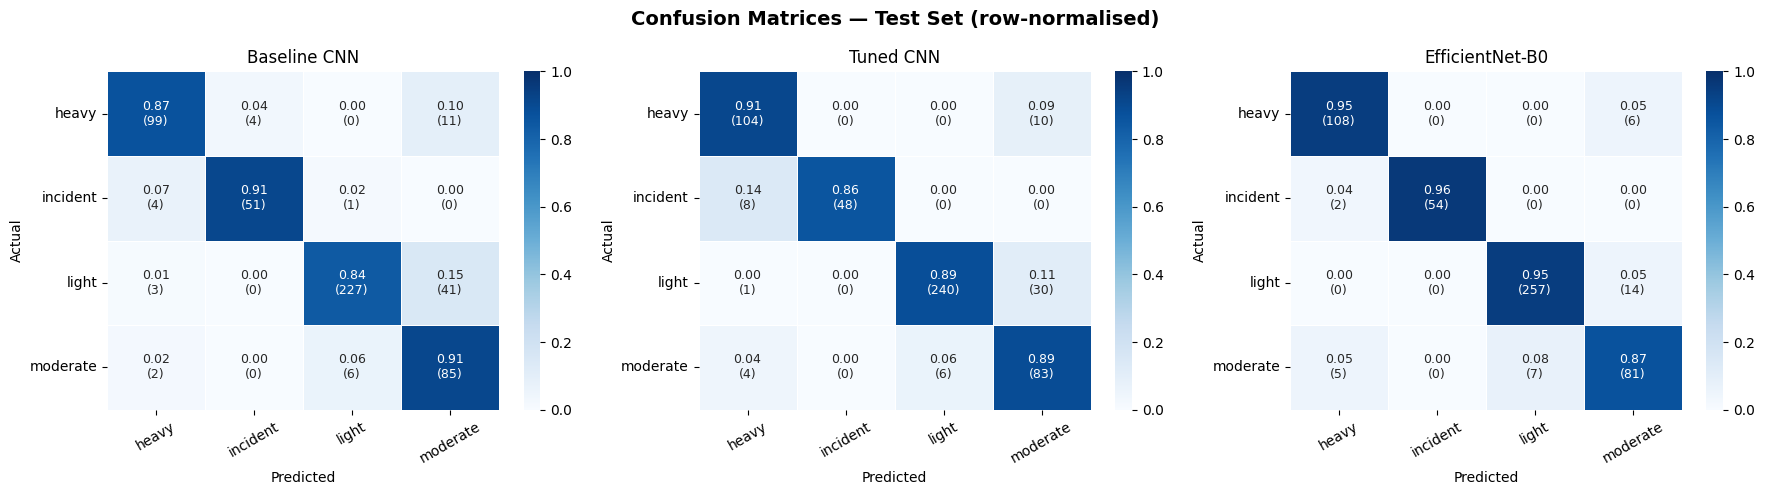

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Set (row-normalised)', fontsize=14, fontweight='bold')

for ax, (name, y_true, probs) in zip(axes, MODELS):
    y_pred  = probs.argmax(axis=1)
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm, dtype=object)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            annot[i, j] = f'{cm_norm[i,j]:.2f}\n({cm[i,j]})'

    sns.heatmap(
        cm_norm, annot=annot, fmt='',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues', ax=ax, vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Reports

In [9]:
for name, y_true, probs in MODELS:
    y_pred = probs.argmax(axis=1)
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))


  Baseline CNN
              precision    recall  f1-score   support

       heavy      0.917     0.868     0.892       114
    incident      0.927     0.911     0.919        56
       light      0.970     0.838     0.899       271
    moderate      0.620     0.914     0.739        93

    accuracy                          0.865       534
   macro avg      0.859     0.883     0.862       534
weighted avg      0.893     0.865     0.872       534


  Tuned CNN
              precision    recall  f1-score   support

       heavy      0.889     0.912     0.900       114
    incident      1.000     0.857     0.923        56
       light      0.976     0.886     0.928       271
    moderate      0.675     0.892     0.769        93

    accuracy                          0.890       534
   macro avg      0.885     0.887     0.880       534
weighted avg      0.907     0.890     0.894       534


  EfficientNet-B0
              precision    recall  f1-score   support

       heavy      0.939    